# QDAC - SRS RF - NI DAQ Bandwidth Test

## Import Libraries

In [1]:
import time
import json
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
from time import sleep

from qcodes import (
    Parameter,
    Measurement,
    Station,
    load_or_create_experiment,
    initialise_or_create_database_at,
)
from qcodes.instrument.channel import ChannelList

from qstl_instruments.qstl_qdac2 import QSTL_QDac2
from qstl_instruments.qstl_nidaq import QSTL_NIDaq
from qstl_instruments.sg386 import SG386

from pyvisa.constants import StopBits, Parity

rm = pyvisa.ResourceManager()
rm.list_resources()

('USB0::0x0957::0x1780::MY60101437::INSTR',
 'ASRL1::INSTR',
 'ASRL3::INSTR',
 'ASRL5::INSTR',
 'ASRL6::INSTR',
 'ASRL20::INSTR',
 'ASRL21::INSTR',
 'ASRL22::INSTR',
 'ASRL23::INSTR',
 'ASRL24::INSTR',
 'ASRL25::INSTR',
 'ASRL26::INSTR',
 'ASRL27::INSTR',
 'GPIB0::27::INSTR')

## Instantiation of Instruments

In [3]:
contacts = {
    "C1" : 1,
    "C2" : 2
}

ai_chans = {
    "I1" : "Dev2/ai0",
    "I2" : "Dev2/ai1",
    "I3" : "Dev2/ai2"
}

# Set up database
initialise_or_create_database_at("./QDAC_IQ_Mod_Bandwidth_Test.db")

qdac2 = QSTL_QDac2(
    name = "qdac2",
    address = "ASRL5::INSTR",
    ramp_rate = 1,
    i_threshold = 2e-9,
    v_limit = 0.5,
    contacts = contacts
)
station = Station(qdac2)

daq = QSTL_NIDaq(
    max_sampling_rate = int(1e6),
    gain = 1e8
)

srs_rf = SG386(
    name = "SRS_SG386",
    address = "GPIB0::27::INSTR"
)

qdac2.ramp_all_channels_to_zero()
qdac2.get_initial_voltages()

Connected to: QDevil QDAC-II (serial:368, firmware:13-1.57) in 0.05s
Connected to: Stanford Research Systems SG386 (serial:s/n004342, firmware:ver1.50.26) in 0.02s


{'C1': 0.0, 'C2': 0.0}

## QDAC2 Parameter Setup

In [83]:
## setup qdac 2 for the 2D sweep
qdac2.free_all_triggers()
qdac2.ext3.delay_s(0)
qdac2.v_limit = 1.2

device1 = "I1"
device2 = "I2"

slow_chans = ["C1"]
fast_chans = ["C2"]

slow_start = 0
slow_end = 0.2
slow_steps = 100

fast_start = 0
fast_end = 0.2
fast_steps = 100
fast_step_time_s = 20e-5

qdac2.channels[0:23].dc_slew_rate_V_per_s("inf")

for i in [slow_start, slow_end, fast_start, fast_end]:
    qdac2.validate_voltages([i])

slow_vs = np.linspace(slow_start, slow_end, slow_steps, endpoint=True)
fast_vs = np.linspace(fast_start, fast_end, fast_steps, endpoint=True)

exp = load_or_create_experiment("2D sweep", "QDAC+NiDAQ_IQ_Samp_Bandwidth_Test")
meas = Measurement(exp=exp, station=station)

Vslow = Parameter(name="Vslow", label=str(slow_chans), unit="V")
Vfast = Parameter(name="Vfast", label=str(fast_chans), unit="V")

I = Parameter(name= "I", label="I", unit="V")
Q = Parameter(name= "Q", label="Q", unit="V")
A = Parameter(name= "A", label="A", unit="V")
Phi = Parameter(name= "theta", label="theta", unit="deg")


meas.register_parameter(Vfast)
meas.register_parameter(Vslow)
meas.register_parameter(I, setpoints = (Vfast, Vslow))
meas.register_parameter(Q, setpoints = (Vfast, Vslow))
meas.register_parameter(A, setpoints = (Vfast, Vslow))
meas.register_parameter(Phi, setpoints = (Vfast, Vslow))

## Measurement (Multi Channel)

In [ ]:
qdac2.channels[0:23].dc_slew_rate_V_per_s("inf")

sweep_time = fast_steps * fast_step_time_s
samples_per_fast_scan_per_channel = fast_steps * int(fast_step_time_s*daq.max_sampling_rate/2)

arrangement = qdac2.arrange(
    contacts= {x: contacts[x] for x in fast_chans},
    output_triggers={"NIDAQ" : 5}
)

sweep = arrangement.virtual_detune(
    contacts = tuple(fast_chans),
    start_V = (fast_start,) * len(fast_chans),
    end_V = (fast_end,) * len(fast_chans),
    steps = fast_steps,
    step_trigger = "NIDAQ",
    step_time_s = fast_step_time_s,
    repetitions = 1
)

InitialConditions = qdac2.get_initial_voltages()

start_time = time.time()
with meas.run() as datasaver:
    loop_counter = 0
    datasaver.dataset.add_metadata(tag="Contacts", metadata=json.dumps(contacts))
    datasaver.dataset.add_metadata(tag="IC", metadata=json.dumps(InitialConditions))
    datasaver.dataset.add_metadata(
        tag = "Sweep_params",
        metadata = json.dumps(
            {
                "slow_chans" : slow_chans,
                "slow_start" : slow_start,
                "slow_end" : slow_end,
                "fast_chans" : fast_chans,
                "fast_start" : fast_start,
                "fast_end" : fast_end,
                "fast_step_time_s" : fast_step_time_s
            }
        )
    )
    for slow_v in slow_vs:
        qdac2.ramp_channels(slow_chans, [slow_v])
        # qdac2.ramp_channels(fast_chans, [fast_start])
        # sleep(0.1)
        result = daq.read_triggered_multi_channels(
            sweep,
            [ai_chans[device1], ai_chans[device2]],
            samples_per_fast_scan_per_channel,
            -1,
            +1,
            sweep_time+1
        )
        result_0 = daq.reshape_array(result[0,:], fast_steps)
        result_1 = daq.reshape_array(result[1,:], fast_steps)
        amp = np.abs(result_0+1j*result_1)
        phase = np.angle(result_0+1j*result_1, deg=True)
        datasaver.add_result(
            (Vslow, [slow_v]*fast_steps),
            (Vfast, fast_vs),
            (I, result_0),
            (Q, result_1),
            (A, amp),
            (Phi, phase)
        )  
            
        loop_counter = loop_counter+1
        print(f'Time elapsed: {np.round(time.time()-start_time, 2)} sec. Loop finished: {loop_counter}/{slow_steps}.')

end_time = time.time()
print(f'Time elapsed: {np.round(end_time-start_time, 2)} sec.')

# qdac2.channels[0:23].dc_slew_rate_V_per_s(1)

Starting experimental run with id: 50. 
Time elapsed: 0.28 sec. Loop finished: 1/100.
Time elapsed: 0.33 sec. Loop finished: 2/100.
Time elapsed: 0.37 sec. Loop finished: 3/100.
Time elapsed: 0.42 sec. Loop finished: 4/100.
Time elapsed: 0.47 sec. Loop finished: 5/100.
Time elapsed: 0.51 sec. Loop finished: 6/100.
Time elapsed: 0.56 sec. Loop finished: 7/100.
Time elapsed: 0.62 sec. Loop finished: 8/100.
Time elapsed: 0.67 sec. Loop finished: 9/100.
Time elapsed: 0.72 sec. Loop finished: 10/100.
Time elapsed: 0.76 sec. Loop finished: 11/100.
Time elapsed: 0.81 sec. Loop finished: 12/100.
Time elapsed: 0.86 sec. Loop finished: 13/100.
Time elapsed: 0.9 sec. Loop finished: 14/100.
Time elapsed: 0.95 sec. Loop finished: 15/100.
Time elapsed: 1.0 sec. Loop finished: 16/100.
Time elapsed: 1.04 sec. Loop finished: 17/100.
Time elapsed: 1.09 sec. Loop finished: 18/100.
Time elapsed: 1.14 sec. Loop finished: 19/100.
Time elapsed: 1.19 sec. Loop finished: 20/100.
Time elapsed: 1.25 sec. Loop fi

In [89]:
import qcodes

## unwrap phase

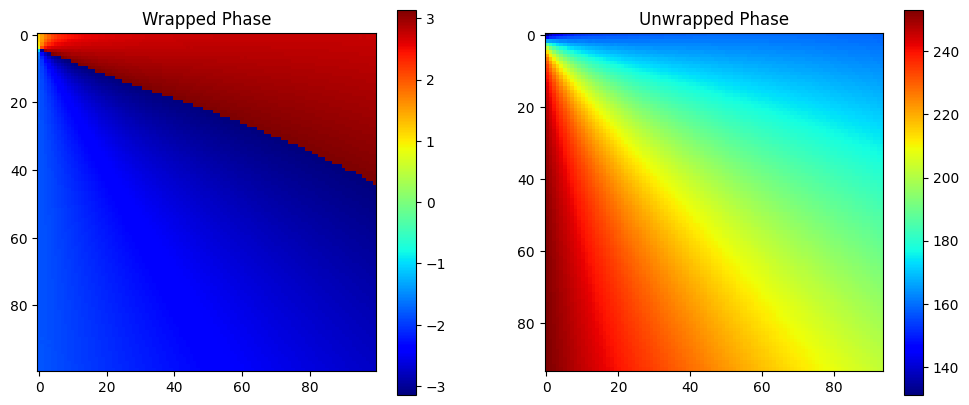

In [96]:
import numpy as np
import qcodes
def unwrap_phase_2d(phase_array):
    """
    Unwrap the phase of a 2D array along both axes.

    Parameters:
    phase_array (np.ndarray): 2D array containing wrapped phase values.

    Returns:
    np.ndarray: 2D array with unwrapped phase values.
    """
    # Unwrap along the first axis (rows)
    unwrapped = np.unwrap(phase_array, axis=0)
    # Then unwrap along the second axis (columns)
    unwrapped = np.unwrap(unwrapped, axis=1)
    return unwrapped

# Example usage
if __name__ == "__main__":
    # Create a sample 2D array with wrapped phase values
    x = np.linspace(0, 4 * np.pi, 100)
    y = np.linspace(0, 4 * np.pi, 100)
    X, Y = np.meshgrid(x, y)
    df = qcodes.load_by_run_spec(captured_run_id=50).to_xarray_dataset()
    wrapped_phase =np.pi*df.theta.values/180  # Simulated wrapped phase

    # Unwrap the phase
    unwrapped_phase = 180*unwrap_phase_2d(wrapped_phase[3:-3, 3:-3])/np.pi

    # Optional: visualize the result
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title("Wrapped Phase")
    plt.imshow(wrapped_phase, cmap='jet')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("Unwrapped Phase")
    plt.imshow(unwrapped_phase, cmap='jet')
    plt.colorbar()
    plt.show()


## Virtual Gate Test

In [ ]:
qdac2.free_all_triggers()
step_time = 20e-6

arrangement = qdac2.arrange(
    contacts= qdac2.contacts,
    output_triggers={"NIDAQ" : 5}
)
fast_steps = 10
slow_steps = 10

sweep = arrangement.virtual_sweep2d(
    inner_contact = "C2",
    inner_voltages = np.linspace(0, 0.2, fast_steps),
    outer_contact = "C1",
    outer_voltages = np.linspace(0, 0.2, slow_steps),
    inner_step_time_s = step_time,
    inner_step_trigger = "NIDAQ"
)

total_samples = int(step_time * daq.max_sampling_rate * fast_steps * slow_steps)
samples_per_step = int(step_time * daq.max_sampling_rate)

start_time = time.time()
result = daq.read_triggered_multi_channels(
    sweep = sweep,
    ch_ids = [ai_chans[device1], ai_chans[device2]],
    num_samples_per_channel = total_samples,
    v_min = -1,
    v_max = +1,
    timeout_sec = 5
)
result_IQ = [
    result[0].reshape(fast_steps, slow_steps, -1).mean(-1),
    result[1].reshape(fast_steps, slow_steps, -1).mean(-1),
]
amp = np.abs(result_IQ[0]+1j*result_IQ[1])
phase = np.angle(result_IQ[1]+1j*result_IQ[1], deg=True)

with meas.run() as datasaver:
    datasaver.add_result(
            (Vslow, [np.linspace(0, 0.2, slow_steps)] * slow_steps),
            (Vfast, [np.linspace(0, 0.2, fast_steps)] * (slow_steps)),
            (I, result_IQ[0]),
            (Q, result_IQ[1]),
            (A, amp),
            (Phi, phase)
        )

end_time = time.time()
print(amp.shape)
print(amp[0:10])
print(f"Total duration : {end_time - start_time} s")

TypeError: scatter() missing 1 required positional argument: 'y'

In [87]:
srs_rf.enable_RF("ON")
srs_rf.frequency(440e6)

In [97]:
srs_rf.enable_RF("OFF")